In [1]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
import yfinance as yf
from datetime import datetime
import scienceplots
from fitting_model import *
from ESN_model import *
from extracter import *
from rollover import * 
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)

import matplotlib.pyplot as plt
import matplotlib as mpl

# Global plotting style for manuscript figures
mpl.rcParams.update({
    "font.family": "Arial",          # or "Helvetica" if available
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "pdf.fonttype": 42,   # editable text in Illustrator
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

Analyzing different mode collecting methods

We analyze whether collecting two quadratures and one quadrature assissting in performance.
- When no mask is applied
- When masked is applied

[*********************100%***********************]  1 of 1 completed


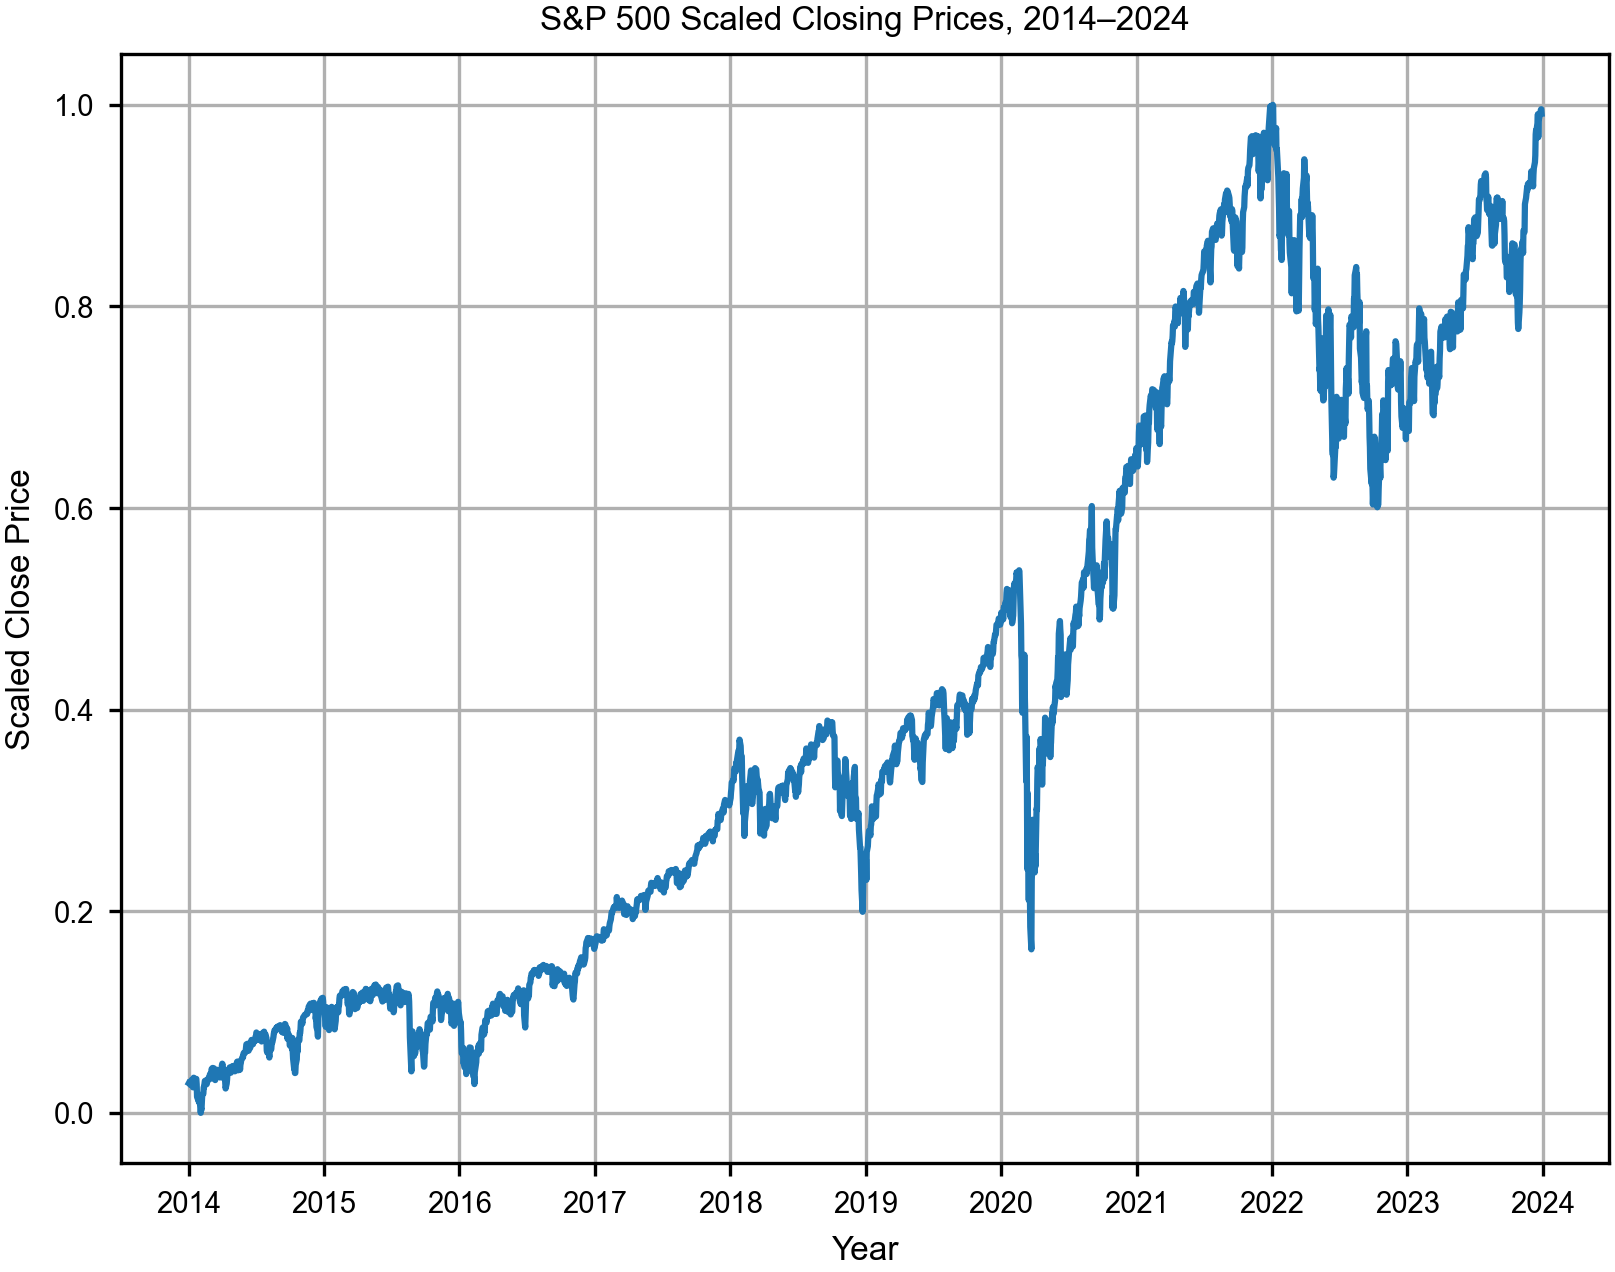

In [19]:
prices = yf.download('^GSPC',start=f"{2014}-01-01",end=f"{2024}-01-01")["Close"]
dataset = prices.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset).flatten()
plt.plot(prices.index, scaled_data)

plt.xlabel("Year")
plt.ylabel("Scaled Close Price")
plt.title("S&P 500 Scaled Closing Prices, 2014–2024")

plt.grid(True)
plt.savefig('SP500')
plt.show()

In [5]:
N=15
rep=1
name = 'SP500'

In [7]:
df = pd.read_csv(f"{name}_Features_2014_2024_rep{rep}_tau{N}.csv")
X_p = extract_delayed_p_or_q_single_column(df,column_name="PQ-15",N=N,repeat_steps=rep) # extract only p
X_p.shape

(2516, 15)

In [9]:
X_pq = extract_delayed_single_column(df,column_name="PQ-15",N=N*2,repeat_steps=rep) # extract both p and q
X_pq.shape

(2516, 30)

In [11]:
column_names = [f"PQ-{i}" for i in range(N-1, 0, -1)] + ["PQ0"]
X_p_row = extract_p_row(df,column_names=column_names,repeat_steps=rep,keep_last=True) # extract p for each row
X_p_row.shape

(2516, 15)

In [12]:
start = 2014
end = 2024
name = '^GSPC'
resultpq = rollover(start, end, name, X_pq, tau=1, Nfading=10)
resultp = rollover(start, end, name, X_p, tau=1, Nfading=10)
resultp_row = rollover(start, end, name, X_p, tau=1, Nfading=10)

C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

Final result:
NRMSE values: [0.04086036 0.12795231 0.12448866 0.08743403 0.14566189 0.36240463
 0.29191463 0.10673517]
Mean NRMSE: 0.16093145851310414
Std NRMSE: 0.10899087096526623



C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%******

Final result:
NRMSE values: [0.10916621 0.21785978 0.1096961  0.08171031 0.10223216 0.44856538
 0.18867778 0.11631377]
Mean NRMSE: 0.17177768725287598
Std NRMSE: 0.12119634559771361



C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%*****

Final result:
NRMSE values: [0.10916621 0.21785978 0.1096961  0.08171031 0.10223216 0.44856538
 0.18867778 0.11631377]
Mean NRMSE: 0.17177768725287598
Std NRMSE: 0.12119634559771361


We perform rollover test with standard deviation

In [21]:
tasks = ['^GSPC', 'AAPL', '^IXIC']
tasks_name = ['SP500', 'AAPL', 'NASDAQ']
start = 2014
end = 2024
reps = [1,10]
tau = 15
performance = {}
for rep in reps:
    for i in range(len(tasks)):
        csv_name = f'{tasks_name[i]}_Features_2014_2024_rep{rep}_tau{tau}.csv'
        df = pd.read_csv(csv_name)
        X_pq = extract_delayed_single_column(df,column_name=f"PQ-15",N=tau*2,repeat_steps=rep)
        results, errors = rollover(start, end, tasks[i], X_pq, tau=1, Nfading=10)
        performance[csv_name] = errors
        print(f'{tasks_name[i]} at rep {rep} and tau 15 has nrmse: ', errors)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04086036 0.12795231 0.12448866 0.08743402 0.14566189 0.36240463
 0.29191463 0.10673517]
Mean NRMSE: 0.1609314586503796
Std NRMSE: 0.10899087139186228
SP500 at rep 1 and tau 15 has nrmse:  [0.04086036 0.12795231 0.12448866 0.08743402 0.14566189 0.36240463
 0.29191463 0.10673517]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.05522775 0.04050372 0.05973678 0.0389066  0.29574138 0.17145889
 0.23455648 0.19627421]
Mean NRMSE: 0.13655072637023508
Std NRMSE: 0.10071563936955558
AAPL at rep 1 and tau 15 has nrmse:  [0.05522775 0.04050372 0.05973678 0.0389066  0.29574138 0.17145889
 0.23455648 0.19627421]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

...

Final result:
NRMSE values: [0.04076724 0.10483578 0.05571228 0.0338171  0.04285708 0.20569997
 0.07637439 0.04126413]
Mean NRMSE: 0.07516599476302113
Std NRMSE: 0.05779956869756436
SP500 at rep 10 and tau 15 has nrmse:  [0.04076724 0.10483578 0.05571228 0.0338171  0.04285708 0.20569997
 0.07637439 0.04126413]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.05332092 0.03446693 0.0427227  0.02302092 0.07078342 0.1019533
 0.07698918 0.06593675]
Mean NRMSE: 0.058649263916710825
Std NRMSE: 0.02548990781588625
AAPL at rep 10 and tau 15 has nrmse:  [0.05332092 0.03446693 0.0427227  0.02302092 0.07078342 0.1019533
 0.07698918 0.06593675]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04156096 0.12689687 0.05621965 0.03424517 0.03946691 0.23575844
 0.06200417 0.03528498]
Mean NRMSE: 0.07892964607705012
Std NRMSE: 0.07025832603927269
NASDAQ at rep 10 and tau 15 has nrmse:  [0.04156096 0.12689687 0.05621965 0.03424517 0.03946691 0.23575844
 0.06200417 0.03528498]


In [41]:
tasks = ['^GSPC', 'AAPL', '^IXIC']
tasks_name = ['SP500', 'AAPL', 'NASDAQ']
esn_performance = run_esn_repeated(
    tasks=tasks,
    tasks_name=tasks_name,
    start=2014,
    end=2024,
    n_runs=100,
    N=30,
    tau=1,
    Nfading=10,
    input_scale=1.0,
    spectral_radius=0.95,
    connectivity=0.1,
)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Running ESN for SP500
Run 1/100
A norm 5.0041144665225294
B norm 3.64394924103169
A/B ratio 1.3732667870822877



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%*******

Final result
NRMSE values: [0.04084785 0.05910095 0.07526762 0.03407122 0.04781904 0.18702672
 0.05295595 0.03559181]
Mean NRMSE: 0.06658514655275981
Std NRMSE: 0.05050550607156285
Run 2/100
A norm 3.849109345257769
B norm 3.0046842746905535
A/B ratio 1.281036206592515


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

...

Final result
NRMSE values: [0.04360316 0.05149196 0.05954203 0.03152183 0.05829152 0.12740368
 0.04703852 0.02993003]
Mean NRMSE: 0.05610284027479449
Std NRMSE: 0.03082052622428456
Run 99/100
A norm 5.951370804175153
B norm 2.8162910324014807
A/B ratio 2.113194529863754


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result
NRMSE values: [0.04432568 0.21773408 0.0659266  0.03133686 0.06242374 0.13439507
 0.04649292 0.02975637]
Mean NRMSE: 0.07904891503625106
Std NRMSE: 0.06515602588670992
Run 100/100
A norm 4.071069128121371
B norm 2.767274174626439
A/B ratio 1.471147732830244


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Final result
NRMSE values: [0.04105665 0.10623195 0.0518779  0.03292519 0.06511166 0.16236901
 0.04690633 0.02945781]
Mean NRMSE: 0.0669920614401196
Std NRMSE: 0.04553485026205502
NASDAQ ESN mean per fold: [0.04293264 0.11343178 0.05848873 0.03314847 0.11819383 0.1161932
 0.0466199  0.02969068]
NASDAQ ESN final mean NRMSE: 0.06983740198803265
NASDAQ ESN std across folds: 0.03916489418816349


In [42]:
reps = [1, 10]
tau_feature = 15
x = np.arange(len(tasks_name))
qr_rep1_errors = [performance[f"{task}_Features_2014_2024_rep1_tau{tau_feature}.csv"] for task in tasks_name]
qr_rep10_errors = [performance[f"{task}_Features_2014_2024_rep10_tau{tau_feature}.csv"] for task in tasks_name]

qr_rep1_means = np.array([np.mean(e) for e in qr_rep1_errors])
qr_rep1_stds  = np.array([np.std(e, ddof=1) for e in qr_rep1_errors])

qr_rep10_means = np.array([np.mean(e) for e in qr_rep10_errors])
qr_rep10_stds  = np.array([np.std(e, ddof=1) for e in qr_rep10_errors])

esn_means = np.array([esn_performance[task]["mean"] for task in tasks_name])
esn_stds = np.array([esn_performance[task]["std"] for task in tasks_name])

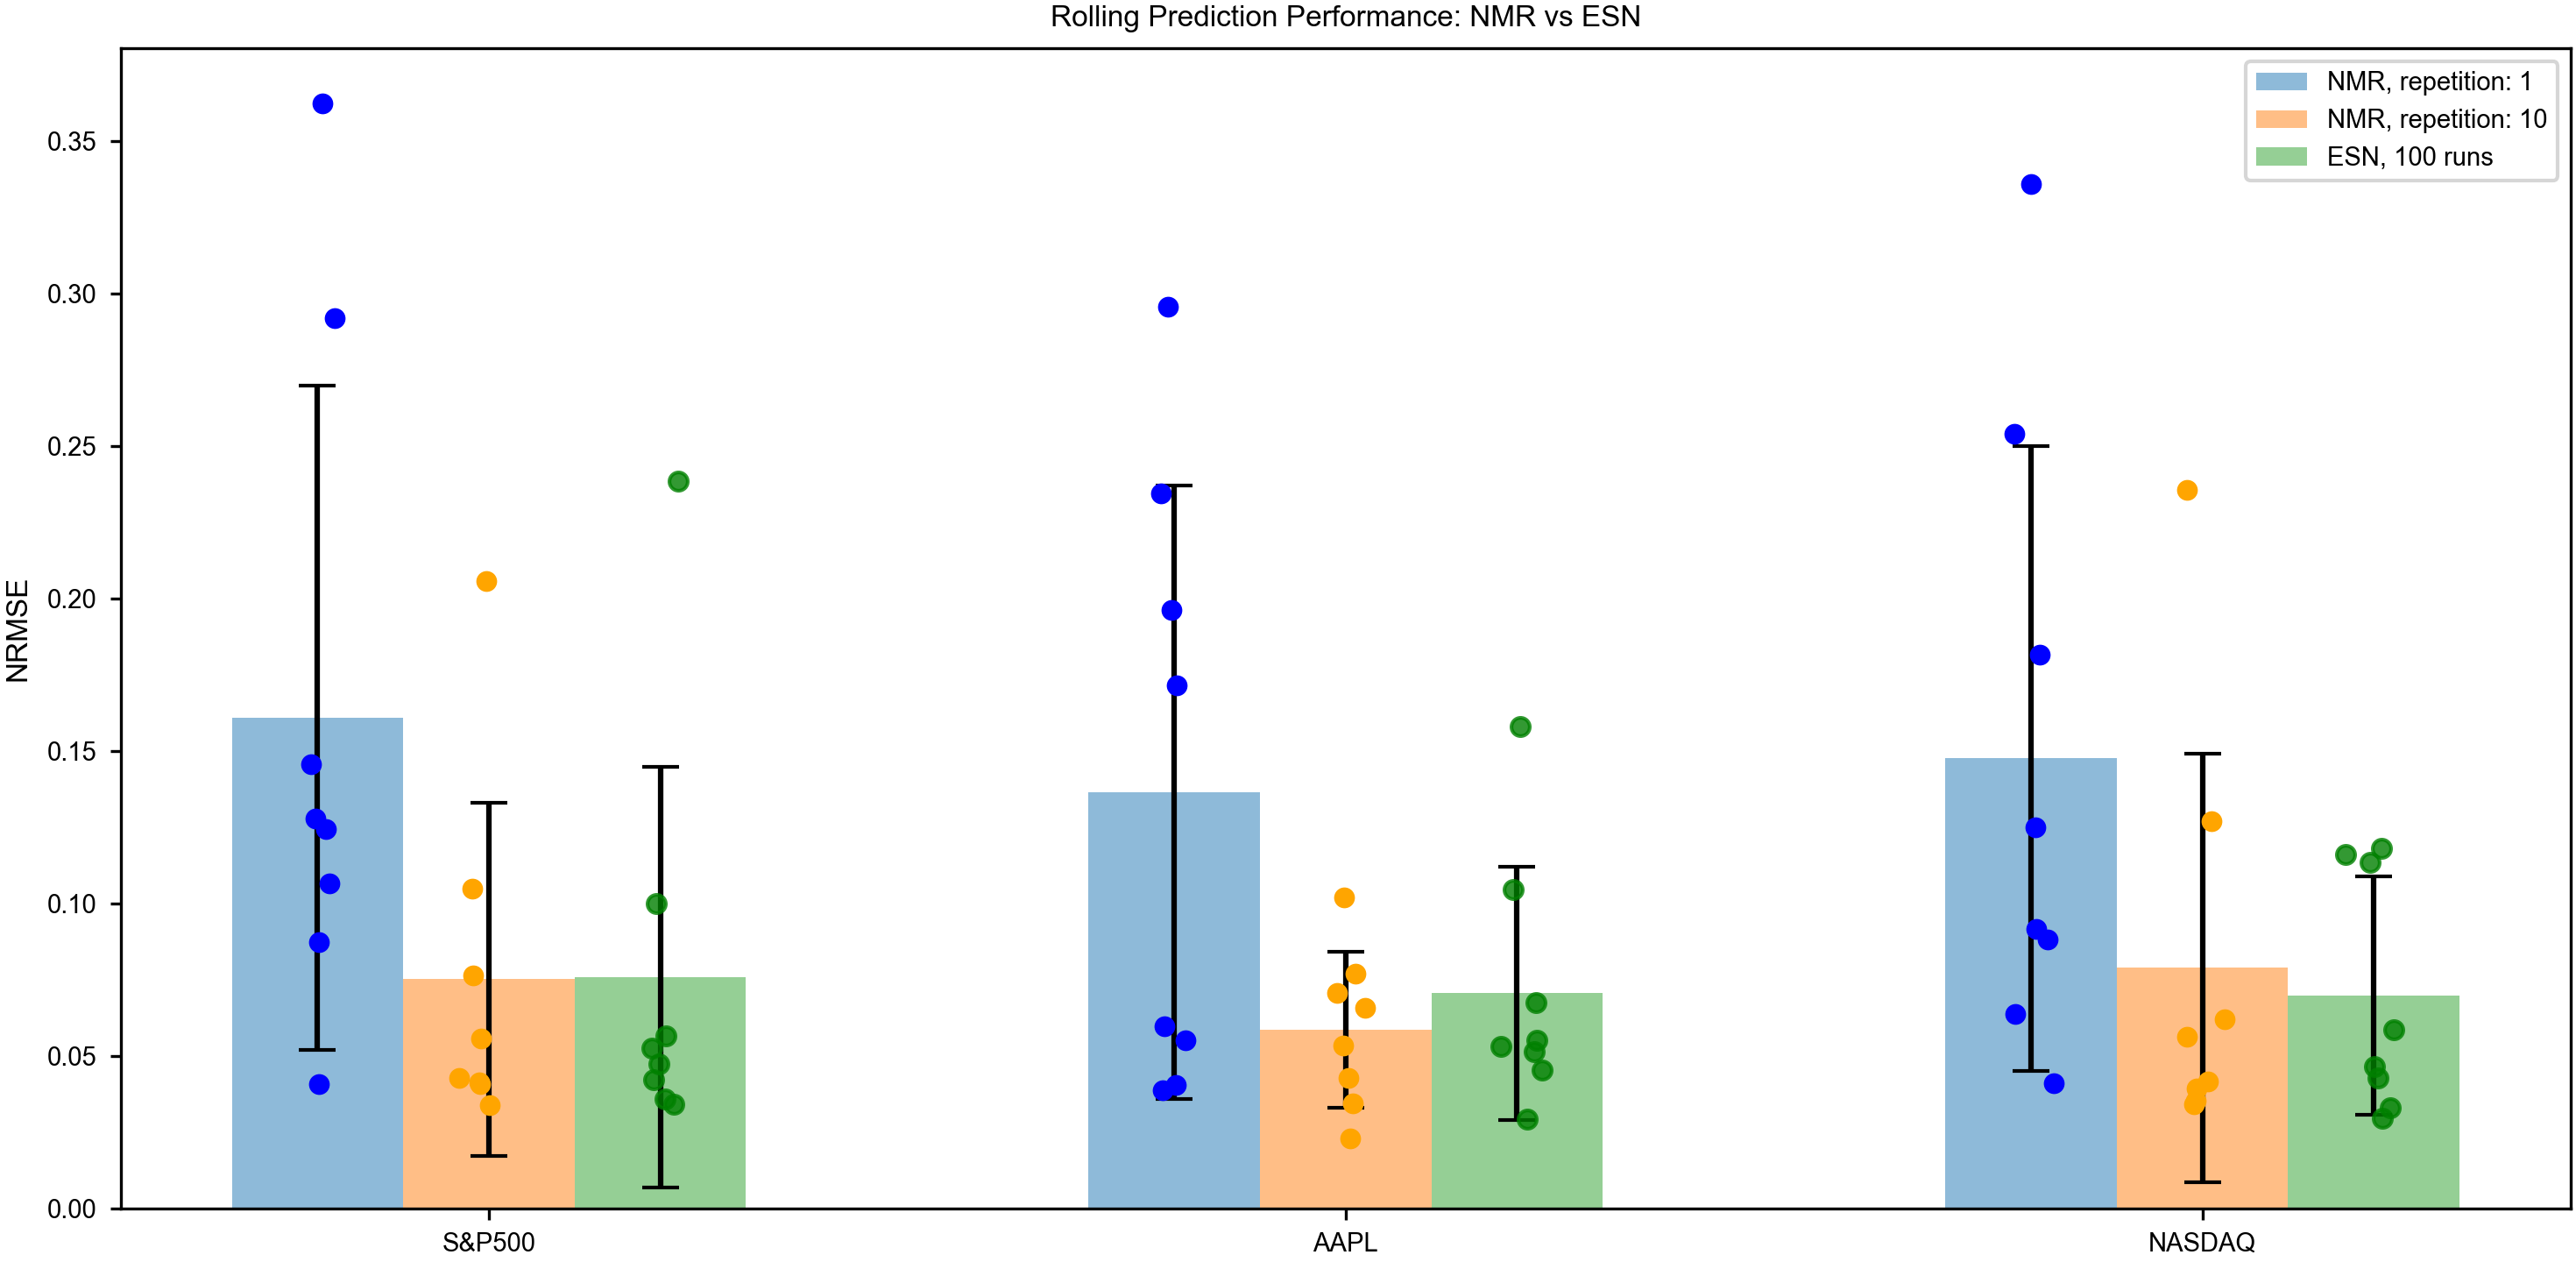

In [49]:
plt.figure(figsize=(10, 5))

tasks_name = ['SP500', 'AAPL', 'NASDAQ']
width = .2
plt.bar(x - width,qr_rep1_means,width,yerr=qr_rep1_stds,capsize=5,label="NMR, repetition: 1",alpha=0.5)
plt.bar(x,qr_rep10_means,width,yerr=qr_rep10_stds,capsize=5,label="NMR, repetition: 10",alpha=0.5)
plt.bar(x + width,esn_means,width,yerr=esn_stds,capsize=5,label="ESN, 100 runs",alpha=0.5)
rng = np.random.default_rng(0)
for i, task in enumerate(tasks_name):
    # QR rep = 1 rolling-window points
    jitter = rng.normal(0, 0.015, size=len(qr_rep1_errors[i]))
    plt.scatter(np.full(len(qr_rep1_errors[i]), x[i] - width) + jitter,qr_rep1_errors[i],s=22,zorder=3,color="blue")
    # QR rep = 10 rolling-window points
    jitter = rng.normal(0, 0.015, size=len(qr_rep10_errors[i]))
    plt.scatter(np.full(len(qr_rep10_errors[i]), x[i]) + jitter,qr_rep10_errors[i],s=22,zorder=3,color='orange')
    # ESN points: one point per rolling fold, averaged over 100 ESN runs
    esn_points = esn_performance[task]["mean_per_fold"]
    jitter = rng.normal(0, 0.015, size=len(esn_points))
    plt.scatter(np.full(len(esn_points), x[i] + width) + jitter,esn_points,s=25,alpha=0.8,zorder=3,color='green')

tasks_name2 = ['S&P500', 'AAPL', 'NASDAQ']
plt.xticks(x, tasks_name2)
plt.ylabel("NRMSE")
#plt.xlabel("Task")
plt.title("Rolling Prediction Performance: NMR vs ESN")
plt.legend()
plt.tight_layout()
plt.savefig('stockprediction.png')
plt.show()

We examine multiple ways of node collecting and observe the performance

In [51]:
start = 2014
end = 2024
reps = [1,10]
taus = [5,10,15,20]
performance = {}
for rep in reps:
    for tau in taus:
        csv_name = f'SP500_Features_2014_2024_rep{rep}_tau{tau}.csv'
        df = pd.read_csv(csv_name)
        X_pq = extract_delayed_single_column(df,column_name=f"PQ-{tau}",N=tau*2,repeat_steps=rep)
        results, errors = rollover(start, end, '^GSPC', X_pq, tau=1, Nfading=10)
        performance[csv_name] = errors
        print(f'SP500 at rep {rep} and tau {tau} has nrmse: ', errors)
        

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04120042 0.11665127 0.11468563 0.07817026 0.11716624 0.53794036
 0.12567056 0.07589454]
Mean NRMSE: 0.150922409293781
Std NRMSE: 0.15901869269111296
SP500 at rep 1 and tau 5 has nrmse:  [0.04120042 0.11665127 0.11468563 0.07817026 0.11716624 0.53794036
 0.12567056 0.07589454]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04126696 0.12743377 0.12123648 0.08654557 0.13877017 0.34294998
 0.20766123 0.09374571]
Mean NRMSE: 0.14495123546688693
Std NRMSE: 0.0932179930342935
SP500 at rep 1 and tau 10 has nrmse:  [0.04126696 0.12743377 0.12123648 0.08654557 0.13877017 0.34294998
 0.20766123 0.09374571]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

...

Final result:
NRMSE values: [0.04062226 0.06099454 0.0550223  0.03148029 0.04055408 0.05892739
 0.05463812 0.03622466]
Mean NRMSE: 0.047307953071794986
Std NRMSE: 0.011334170954338967
SP500 at rep 10 and tau 10 has nrmse:  [0.04062226 0.06099454 0.0550223  0.03148029 0.04055408 0.05892739
 0.05463812 0.03622466]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04076724 0.10483578 0.05571228 0.0338171  0.04285708 0.20569997
 0.07637439 0.04126413]
Mean NRMSE: 0.07516599476302113
Std NRMSE: 0.05779956869756436
SP500 at rep 10 and tau 15 has nrmse:  [0.04076724 0.10483578 0.05571228 0.0338171  0.04285708 0.20569997
 0.07637439 0.04126413]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Final result:
NRMSE values: [0.04032277 0.11915083 0.06001049 0.03381435 0.04260028 0.3385205
 0.12160644 0.04975213]
Mean NRMSE: 0.10072222377090298
Std NRMSE: 0.10217778511751946
SP500 at rep 10 and tau 20 has nrmse:  [0.04032277 0.11915083 0.06001049 0.03381435 0.04260028 0.3385205
 0.12160644 0.04975213]


In [53]:
import numpy as np
import matplotlib.pyplot as plt

reps = [1, 10]
taus = [5, 10, 15, 20]

x = np.arange(len(taus))
width = 0.35

rep1_errors = [performance[f"SP500_Features_2014_2024_rep1_tau{tau}.csv"] for tau in taus]
rep10_errors = [performance[f"SP500_Features_2014_2024_rep10_tau{tau}.csv"] for tau in taus]

rep1_means = np.array([np.mean(e) for e in rep1_errors])
rep1_stds  = np.array([np.std(e, ddof=1) for e in rep1_errors])

rep10_means = np.array([np.mean(e) for e in rep10_errors])
rep10_stds  = np.array([np.std(e, ddof=1) for e in rep10_errors])

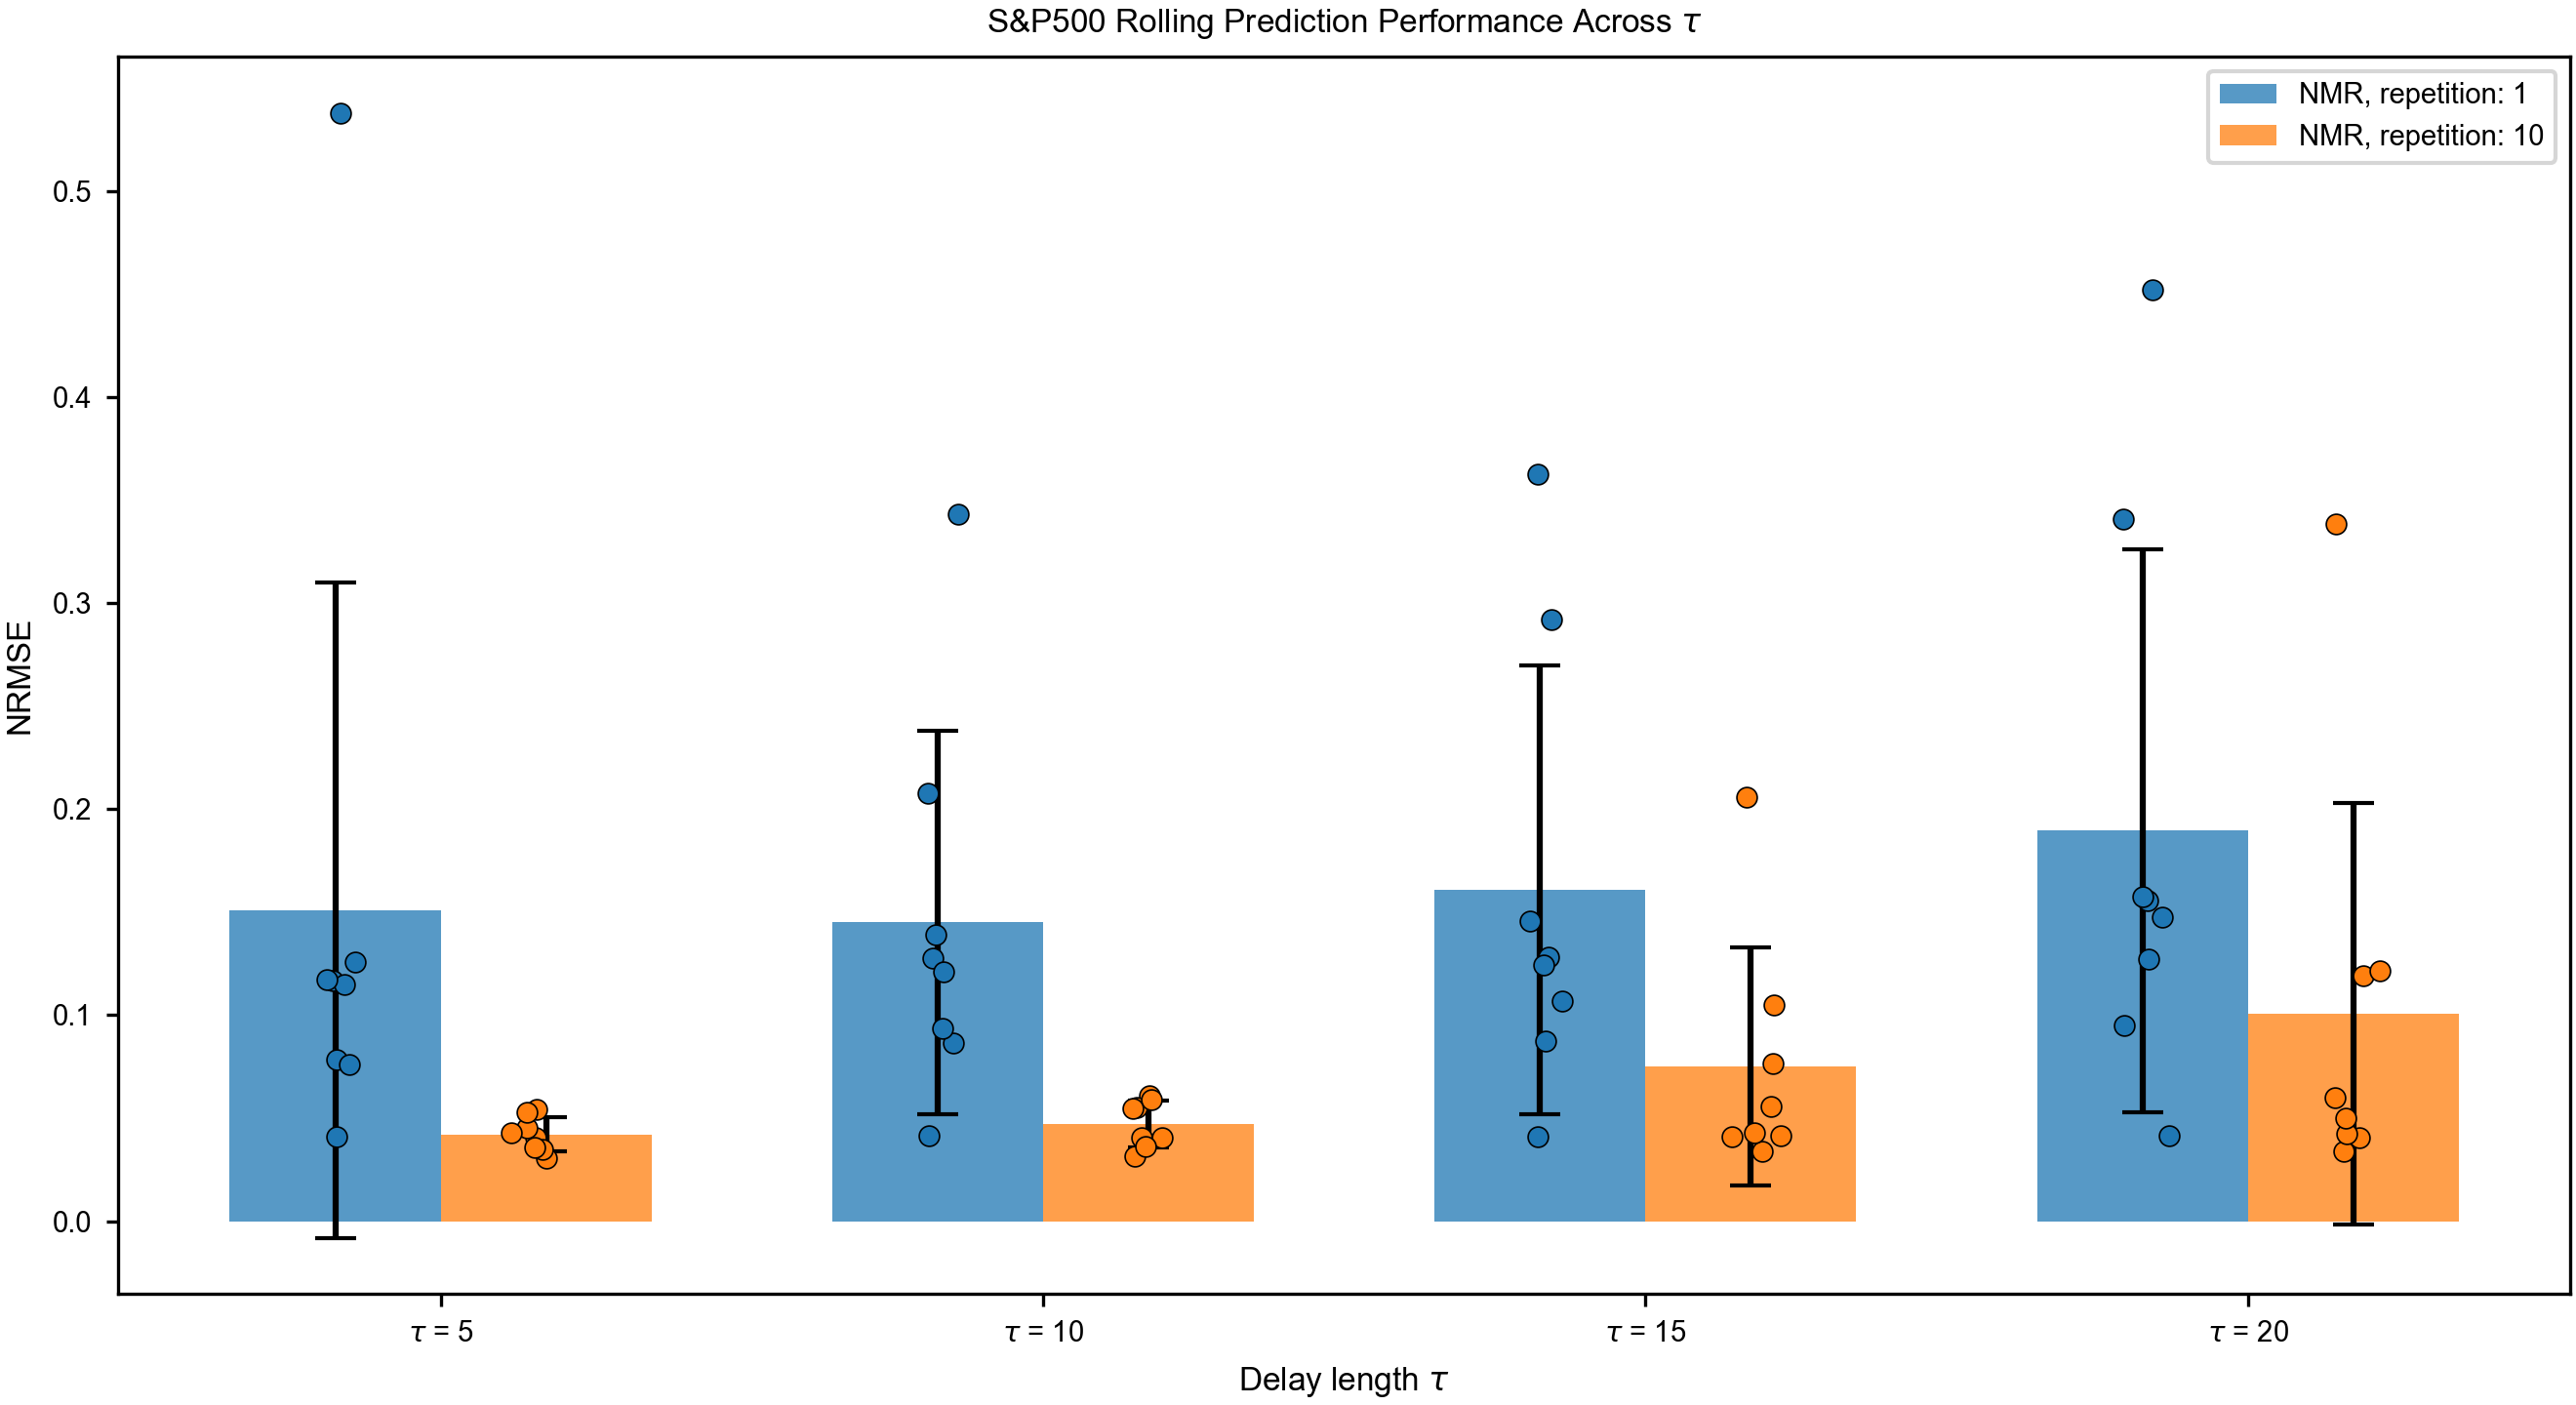

In [59]:
plt.figure(figsize=(9, 5))

plt.bar(x - width / 2,rep1_means,width,yerr=rep1_stds,capsize=5,label="NMR, repetition: 1",color="tab:blue",alpha=0.75)
plt.bar(x + width / 2,rep10_means,width,yerr=rep10_stds,capsize=5,label="NMR, repetition: 10",color="tab:orange",alpha=0.75)

rng = np.random.default_rng(0)

for i, tau in enumerate(taus):
    jitter = rng.normal(0, 0.025, size=len(rep1_errors[i]))
    plt.scatter(np.full(len(rep1_errors[i]), x[i] - width / 2) + jitter,rep1_errors[i],s=25,color="tab:blue",edgecolor="black",linewidth=0.4,zorder=3)

    jitter = rng.normal(0, 0.025, size=len(rep10_errors[i]))
    plt.scatter(np.full(len(rep10_errors[i]), x[i] + width / 2) + jitter,rep10_errors[i],s=25,color="tab:orange",edgecolor="black",linewidth=0.4,zorder=3)

plt.xticks(x, [rf"$τ$ = {tau}" for tau in taus])
plt.ylabel("NRMSE")
plt.xlabel(r"Delay length $\tau$")
plt.title(r"S&P500 Rolling Prediction Performance Across $\tau$")
plt.savefig('stockprediction2.png')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

start = 2014
end = 2024

rep = 10  # choose one repeat_steps first
taus = [5, 10, 15, 20]

# number of collected nodes/features
# must be even because each delay gives P and Q
N_values = [2, 4, 6, 8, 10, 20, 30, 40]

performance = {}

for tau in taus:
    csv_name = f"SP500_Features_2014_2024_rep{rep}_tau{tau}.csv"
    df = pd.read_csv(csv_name)

    mean_errors = []
    std_errors = []

    for N in N_values:
        X_pq = extract_delayed_single_column(df,column_name=f"PQ-{tau}",N=N,repeat_steps=rep)
        results, errors = rollover(start,end,"^GSPC",X_pq,tau=1,Nfading=10)
        mean_errors.append(np.mean(errors))
        std_errors.append(np.std(errors))
        print(f"tau={tau}, N={N}, mean NRMSE={np.mean(errors):.4f}, std={np.std(errors):.4f}")

    performance[tau] = {
        "N_values": N_values,
        "mean_errors": mean_errors,
        "std_errors": std_errors
    }

C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

Final result:
NRMSE values: [0.04125957 0.093006   0.07901776 0.05587201 0.06685613 0.08152438
 0.05997337 0.04346785]
Mean NRMSE: 0.06512213314263363
Std NRMSE: 0.018489544998172607
tau=5, N=2, mean NRMSE=0.0651, std=0.0173


C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

Final result:
NRMSE values: [0.04086477 0.12216134 0.0581712  0.05307643 0.04569907 0.03514092
 0.05433213 0.03653973]
Mean NRMSE: 0.05574820017562332
Std NRMSE: 0.02813702750896633
tau=5, N=4, mean NRMSE=0.0557, std=0.0263


C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

...

Final result:
NRMSE values: [0.04042868 0.05255156 0.05219621 0.03330432 0.04165715 0.33445888
 0.1253073  0.05152067]
Mean NRMSE: 0.09142809567723095
Std NRMSE: 0.10233792398314101
tau=20, N=20, mean NRMSE=0.0914, std=0.0957


C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

Final result:
NRMSE values: [0.04043791 0.10780601 0.05258747 0.03353953 0.042248   0.33838179
 0.12777978 0.05064528]
Mean NRMSE: 0.09917822095824166
Std NRMSE: 0.1025648862644732
tau=20, N=30, mean NRMSE=0.0992, std=0.0959


C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

Final result:
NRMSE values: [0.04032277 0.11915084 0.06001048 0.03381435 0.04260028 0.3385205
 0.12160644 0.04975213]
Mean NRMSE: 0.10072222468078218
Std NRMSE: 0.10217778599763086
tau=20, N=40, mean NRMSE=0.1007, std=0.0956


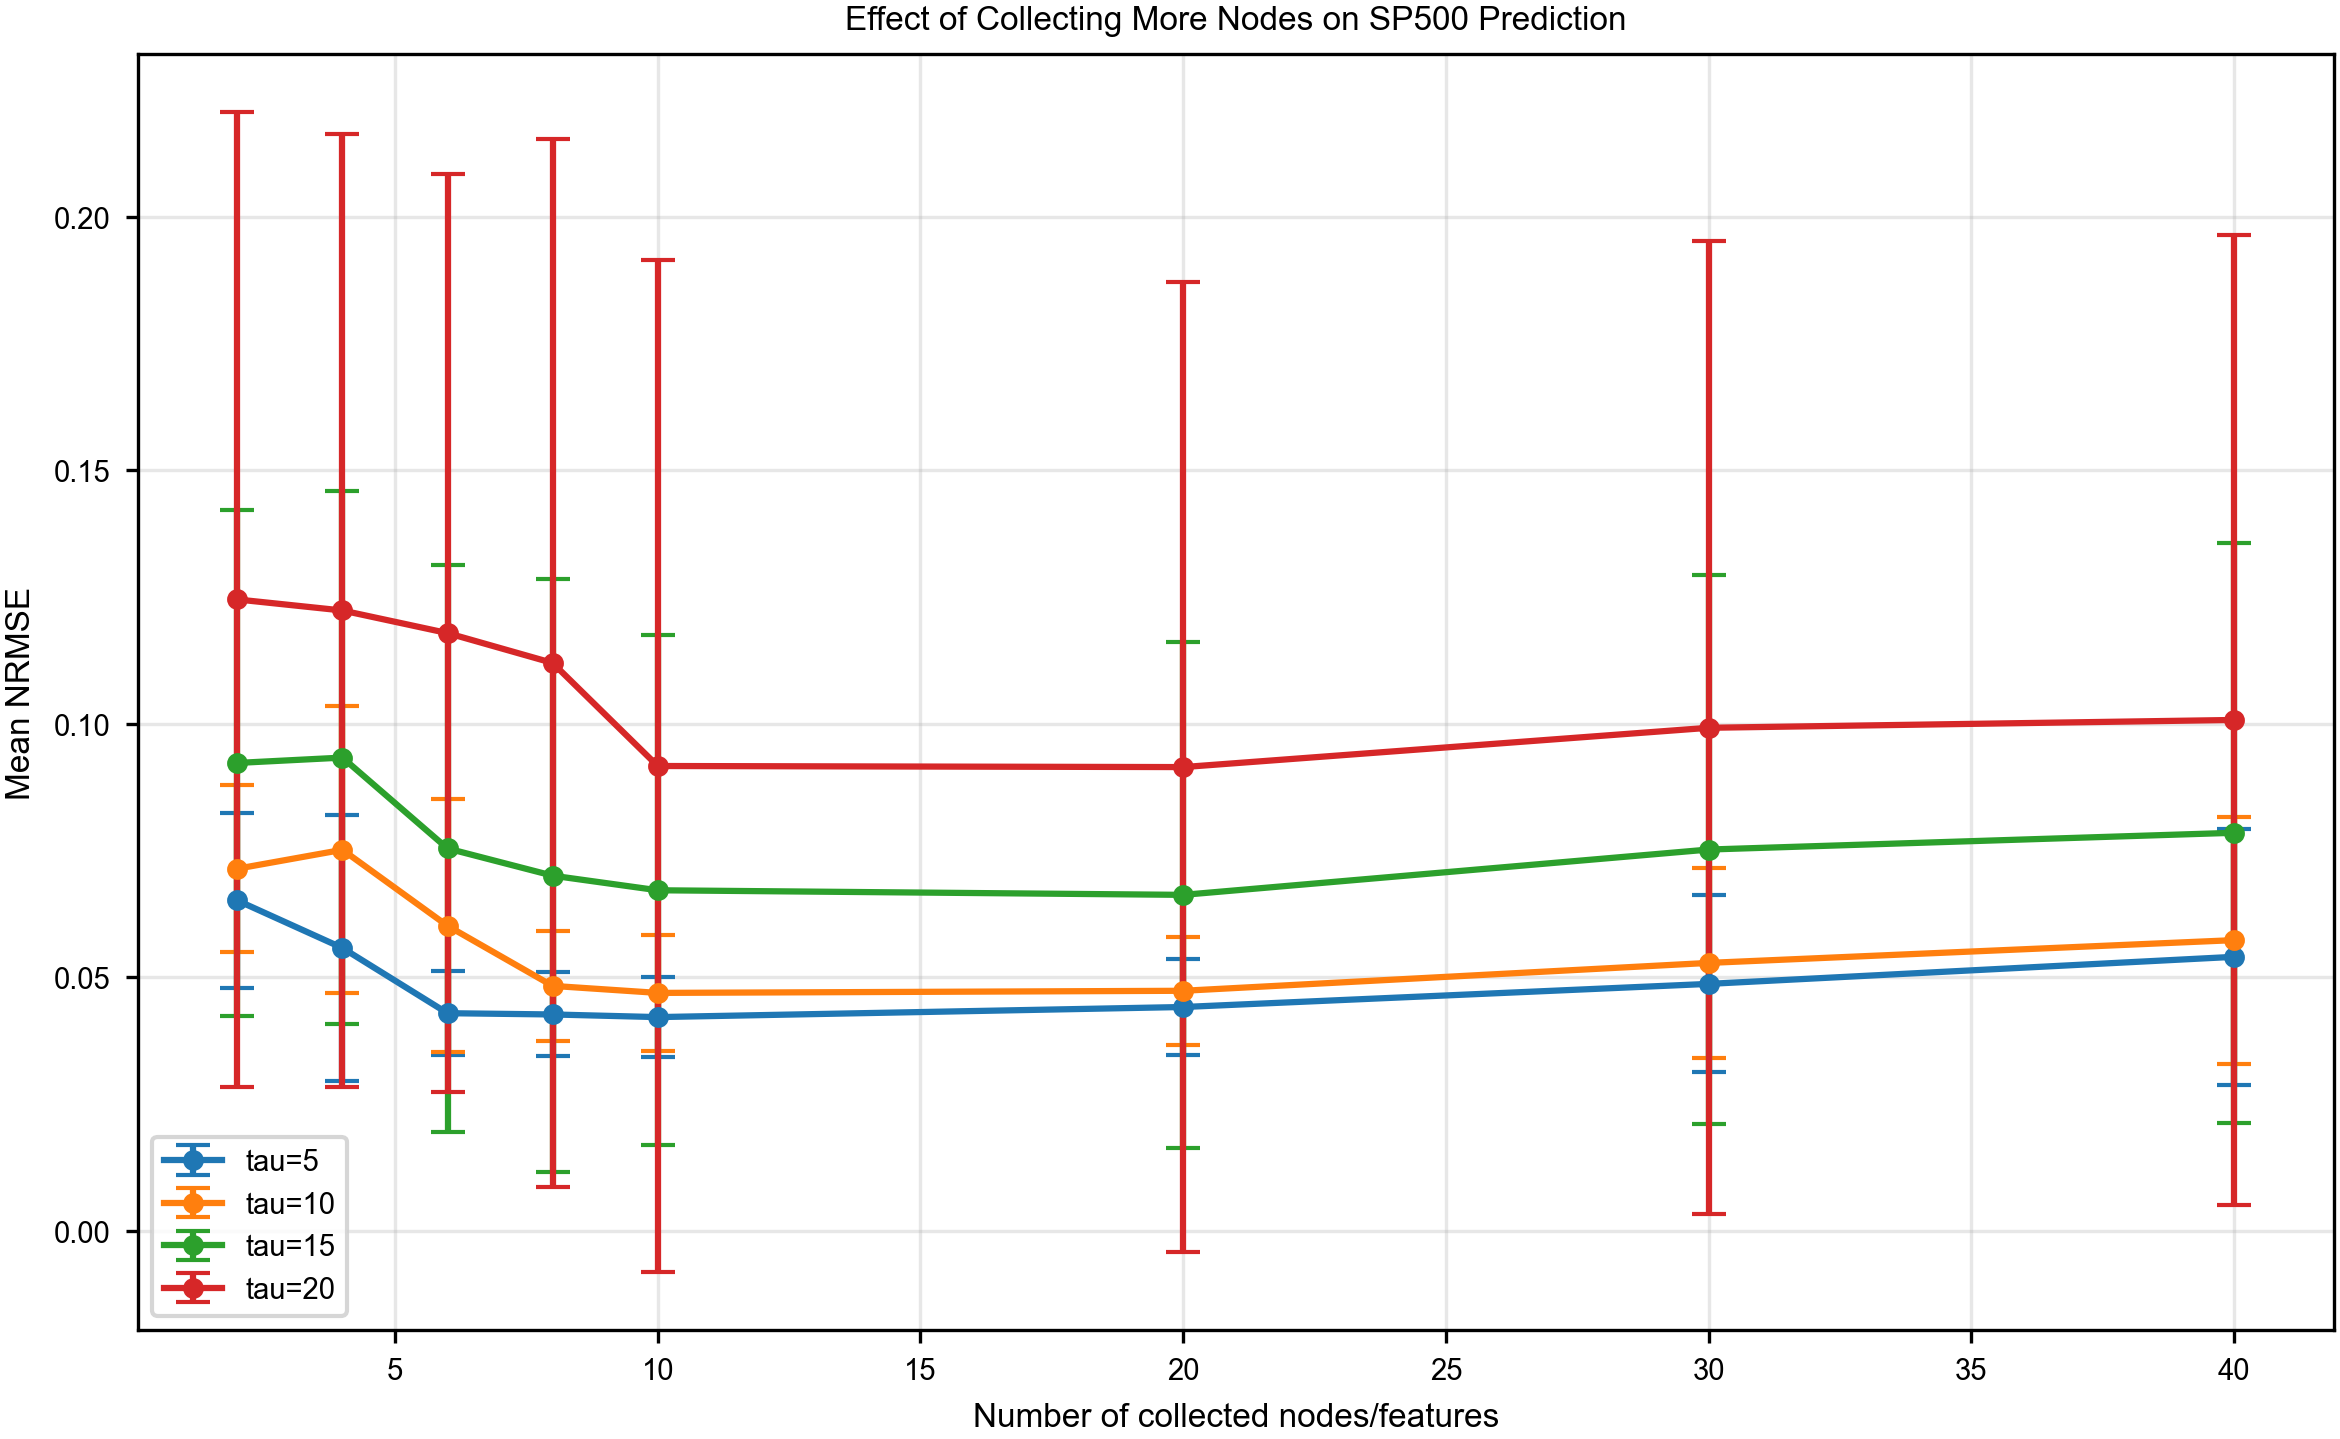

In [34]:
plt.figure(figsize=(8, 5))
taus = [5,10,15,20]
for tau in taus:
    plt.errorbar(
        performance[tau]["N_values"],
        performance[tau]["mean_errors"],
        yerr=performance[tau]["std_errors"],
        marker="o",
        capsize=4,
        label=f"tau={tau}"
    )

plt.xlabel("Number of collected nodes/features")
plt.ylabel("Mean NRMSE")
plt.title("Effect of Collecting More Nodes on SP500 Prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()